EP2 - Reconhecimento de Folhas de Plantas

Parte 2: Extração de Características da Folha

Ísis Ardisson Logullo - 7577410

1 - Carregamento do Dataset

Mapeamento de cada tipo de planta para os seus respectivos intervalos de arquivos, conforme especificado na tabela. As imagens são carregadas do arquivo Leaves.zip encontrado no enunciado do EP2, estruturando-as em um dicionário para fácil acesso nas etapas subsequentes. É necessário ter o arquivo baixado na mesma pasta onde se encontra esse jupiter notebook.

In [55]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['image.cmap'] = 'gray'

ARQUIVO_ZIP_LOCAL = "Leaves.zip"
DIRETORIO_DATASET = "Leaves"

def extrair_e_carregar_imagens_local(arquivo_zip, diretorio_destino):
    if not os.path.exists(diretorio_destino):
        print(f"Pasta '{diretorio_destino}' não encontrada.")

        if os.path.exists(arquivo_zip):
            print(f"Arquivo '{arquivo_zip}' detectado localmente. Iniciando extração...")
            try:
                with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
                    zip_ref.extractall(diretorio_destino)
                print("Extração concluída com sucesso!")
            except Exception as e:
                print(f"Erro ao tentar extrair o arquivo ZIP: {e}")
                return {}
        else:
            print(f"Erro: O arquivo '{arquivo_zip}' não foi encontrado na pasta atual.")
            print("Certifique-se de que o arquivo ZIP está exatamente no mesmo diretório deste script.")
            return {}
    else:
        print(f"A pasta '{diretorio_destino}' já existe. Pulando extração e lendo os arquivos.")

    dataset_direto = {}

    print("\nIniciando o carregamento das imagens...")
    for raiz, _, arquivos in os.walk(diretorio_destino):
        for arquivo in arquivos:
            nome_puro, extensao = os.path.splitext(arquivo)

            if nome_puro.isdigit() and extensao.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                numero_id = int(nome_puro)
                caminho_completo = os.path.join(raiz, arquivo)

                try:
                    img_array = plt.imread(caminho_completo)
                    dataset_direto[numero_id] = img_array
                except Exception as err:
                    print(f"Erro ao ler o arquivo {arquivo}: {err}")

    print(f"Concluído! Total de imagens salvas na memória: {len(dataset_direto)}")
    return dataset_direto

folhas_dados_direto = extrair_e_carregar_imagens_local(ARQUIVO_ZIP_LOCAL, DIRETORIO_DATASET)

Pasta 'Leaves' não encontrada.
Arquivo 'Leaves.zip' detectado localmente. Iniciando extração...
Extração concluída com sucesso!

Iniciando o carregamento das imagens...
Concluído! Total de imagens salvas na memória: 1907


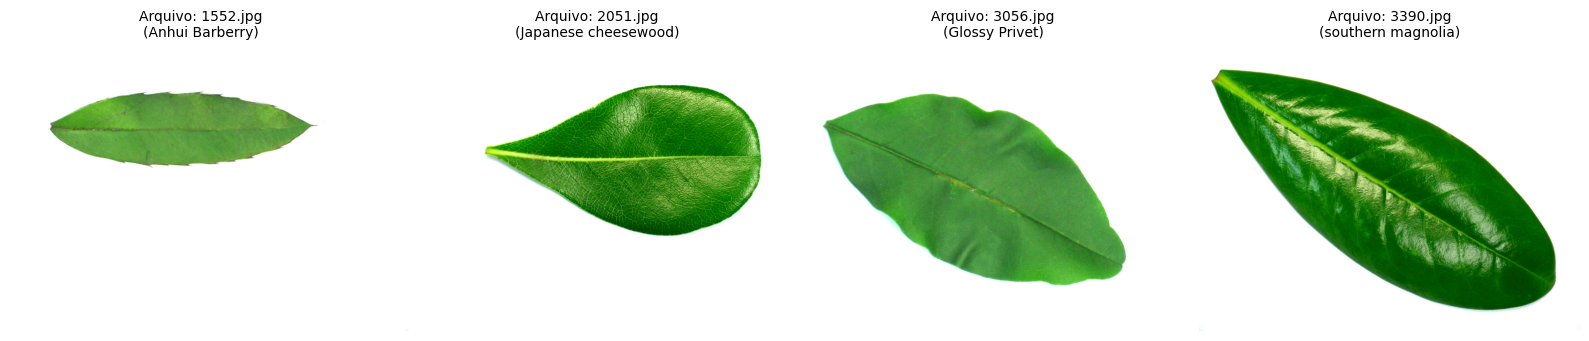

In [60]:
MAPEAMENTO_PLANTAS = {
    1: ("pubescent bamboo", 1001, 1059),
    2: ("Chinese horse chestnut", 1060, 1122),
    3: ("Anhui Barberry", 1552, 1616),
    4: ("Chinese redbud", 1123, 1194),
    5: ("true indigo", 1195, 1267),
    6: ("Japanese maple", 1268, 1323),
    7: ("Nanmu", 1324, 1385),
    8: ("castor aralia", 1386, 1437),
    9: ("Chinese cinnamon", 1497, 1551),
    10: ("goldenrain tree", 1438, 1496),
    11: ("Bigfruited -Holly", 2001, 2050),
    12: ("Japanese cheesewood", 2051, 2113),
    14: ("wintersweet", 2114, 2165),
    15: ("camphortree", 2166, 2230),
    16: ("Japan Arrowwood", 2231, 2290),
    17: ("sweet osmanthus", 2291, 2346),
    18: ("deodar", 2347, 2423),
    19: ("ginkgo, maidenhair tree", 2424, 2485),
    20: ("Crape myrtle, Crepe myrtle", 2486, 2546),
    21: ("oleander", 2547, 2612),
    22: ("yew plum pine", 2616, 2675),
    23: ("Japanese Flowering Cherry", 3001, 3055),
    24: ("Glossy Privet", 3056, 3110),
    25: ("Chinese Toon", 3111, 3175),
    26: ("peach", 3176, 3229),
    27: ("Ford Woodlotus", 3230, 3281),
    28: ("trident maple", 3282, 3334),
    29: ("Beale's barberry", 3335, 3389),
    30: ("southern magnolia", 3390, 3446),
    31: ("Canadian poplar", 3447, 3510),
    32: ("Chinese tulip tree", 3511, 3563),
    33: ("tangerine", 3566, 3621)
}

def obter_nome_especie_por_id_arquivo(id_arquivo):
    """
    Varre o MAPEAMENTO_PLANTAS para descobrir a espécie com base no
    intervalo numérico [ID_inicio, ID_fim].
    """
    for chave_especie, (nome, inicio, fim) in MAPEAMENTO_PLANTAS.items():
        if inicio <= id_arquivo <= fim:
            return nome
    return "Espécie Desconhecida"


def visualizar_folhas_por_numero(dataset, numeros_para_mostrar):
    qtd = len(numeros_para_mostrar)
    if qtd == 0:
        return

    fig, axes = plt.subplots(1, qtd, figsize=(4 * qtd, 4.5))
    if qtd == 1:
        axes = [axes]

    for idx, num in enumerate(numeros_para_mostrar):
        nome_especie = obter_nome_especie_por_id_arquivo(num)

        if num in dataset:
            img = dataset[num]
            axes[idx].imshow(img)
            axes[idx].set_title(f"Arquivo: {num}.jpg\n({nome_especie})", fontsize=10)
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"Arquivo {num}.jpg\nnão encontrado",
                           ha='center', va='center', color='red')
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


# Planta 3  (Anhui Barberry): 1552
# Planta 12 (Japanese cheesewood): 2051
# Planta 24 (Glossy Privet): 3056
# Planta 30 (southern magnolia): 3390
IDS_REAIS_TESTE = [1552, 2051, 3056, 3390]

if 'folhas_dados_direto' in globals() and folhas_dados_direto:
    visualizar_folhas_por_numero(folhas_dados_direto, numeros_para_mostrar=IDS_REAIS_TESTE)

2 - Funções de Apoio e Processamento de Imagens

Obtendo as bordas com operações morfológicas (erosão para o fator de suavização $S$) e usando algoritmos básicos de processamento de imagens matriciais.  Função para converter imagens para escala de cinza, binarizá-las via limiar de Otsu (ou valor fixo robusto para o fundo branco) e extrair os pixels pertencentes à borda (fronteira) da folha.  

RESULTADO DE PROCESSAMENTO - ID DO DATASET: 1552
NOME DA ESPÉCIE: ANHUI BARBERRY
Dimensões originais da imagem:      (1200, 1600, 3)
Número total de pixels da borda:     2609 pixels
Amostra das coordenadas da borda (X, Y):
[[804 195]
 [805 195]
 [806 195]
 [807 195]
 [808 195]]


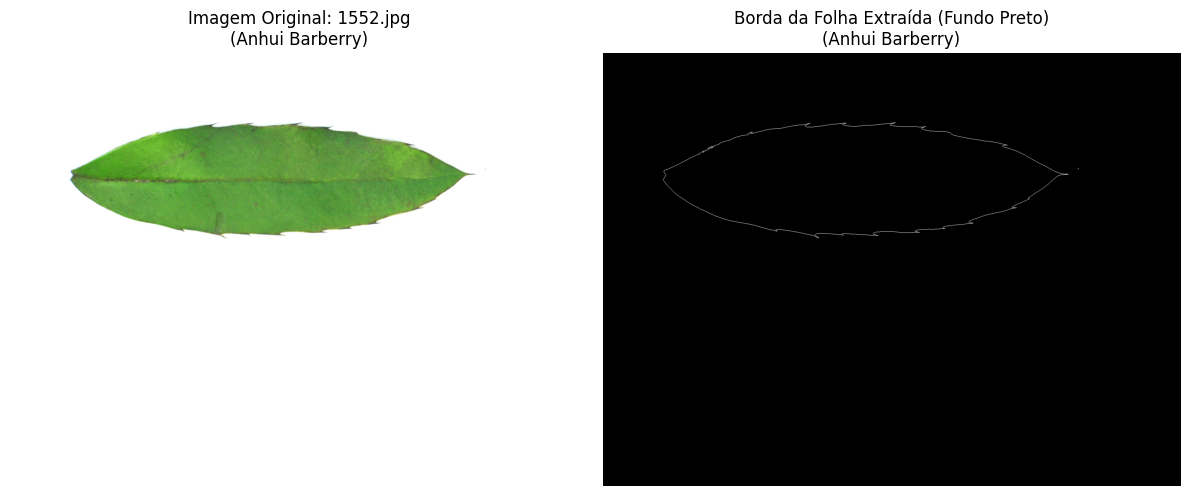

In [59]:
def converter_para_cinza(img):
    if len(img.shape) == 3:
        return (0.2989 * img[:,:,0] + 0.5870 * img[:,:,1] + 0.1140 * img[:,:,2]).astype(np.uint8)
    return img.copy()

def binarizar_imagem(img_gray):
    # fundo branco > 200
    # folha < 200.
    binaria = (img_gray < 200).astype(np.uint8)
    return binaria

def obter_pixels_borda(binaria):
    H, W = binaria.shape
    borda_mascara = np.zeros_like(binaria)

    for y in range(1, H-1):
        for x in range(1, W-1):
            if binaria[y, x] == 1:
                if (binaria[y-1, x] == 0 or binaria[y+1, x] == 0 or
                    binaria[y, x-1] == 0 or binaria[y, x+1] == 0):
                    borda_mascara[y, x] = 1

    coordenadas_y, coordenadas_x = np.where(borda_mascara == 1)
    return np.column_stack((coordenadas_x, coordenadas_y))


###### Visualizacao ########

ID_TESTE = 1552

if 'folhas_dados_direto' in globals() and ID_TESTE in folhas_dados_direto:
    img_original = folhas_dados_direto[ID_TESTE]

    nome_especie = obter_nome_especie_por_id_arquivo(ID_TESTE)

    img_cinza = converter_para_cinza(img_original)
    img_binaria = binarizar_imagem(img_cinza)
    pontos_borda = obter_pixels_borda(img_binaria)

    matriz_borda_visual = np.zeros_like(img_binaria)
    if len(pontos_borda) > 0:
        matriz_borda_visual[pontos_borda[:, 1], pontos_borda[:, 0]] = 1

    print("="*65)
    print(f"RESULTADO DE PROCESSAMENTO - ID DO DATASET: {ID_TESTE}")
    print(f"NOME DA ESPÉCIE: {nome_especie.upper()}")
    print("="*65)
    print(f"Dimensões originais da imagem:      {img_original.shape}")
    print(f"Número total de pixels da borda:     {len(pontos_borda)} pixels")
    print(f"Amostra das coordenadas da borda (X, Y):\n{pontos_borda[:5]}")
    print("="*65)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img_original)
    axes[0].set_title(f"Imagem Original: {ID_TESTE}.jpg\n({nome_especie})")
    axes[0].axis('off')

    axes[1].imshow(matriz_borda_visual, cmap='gray')
    axes[1].set_title(f"Borda da Folha Extraída (Fundo Preto)\n({nome_especie})")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Erro: O ID {ID_TESTE} não foi encontrado dentro do dicionário 'folhas_dados_direto'.")

3 - Análise de Componentes Principais (PCA) em 2D para Alinhamento das Folhas

O cálculo manual do Comprimento Fisiológico ($L_p$) e da Largura Fisiológica ($W_p$) é feito marcando as extremidades da folha. Para automatizar esse processo, utiliza-se o PCA (Análise de Componentes Principais) para rotacionar o sistema de coordenadas de modo a coincidir com os eixos naturais da folha:

- Centroide: Calcula o ponto médio $\bar{x}$ dos pontos da borda.  
- Centralização: Subtrai o centroide de todos os pontos da borda.
- Matriz de Covariância: Calcula a covariância $\Sigma$ para encontrar as direções de maior variância.  
- Autovalores e Autovetores: Encontra os componentes principais $u_1$ (comprimento) e $u_2$ (largura).

ANÁLISE DE COMPONENTES PRINCIPAIS (PCA) - ID: 1552
ESPÉCIE: ANHUI BARBERRY
Centroide calculado (X_médio, Y_médio): (725.01, 349.64)
Vetor Diretor do Eixo Principal (u1):    [-1.0000, -0.0057]
Vetor Diretor do Eixo Secundário (u2):   [0.0057, -1.0000]
Ortogonalidade (u1 . u2) (deve ser ~0):  0.0e+00


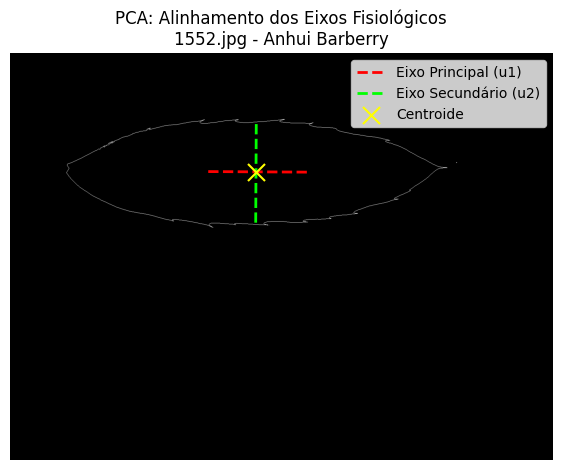

In [58]:
def calcular_pca_borda(pontos_borda):
    X = pontos_borda.astype(float)
    n = X.shape[0]

    centroide = np.mean(X, axis=0)
    X_centralizado = X - centroide

    cov_matrix = (1.0 / (n - 1)) * np.dot(X_centralizado.T, X_centralizado)
    autovalores, autovetores = np.linalg.eigh(cov_matrix)

    indices_ordenados = np.argsort(autovalores)[::-1]
    autovalores = autovalores[indices_ordenados]
    autovetores = autovetores[:, indices_ordenados]

    u1 = autovetores[:, 0] / np.linalg.norm(autovetores[:, 0])
    u2 = autovetores[:, 1] / np.linalg.norm(autovetores[:, 1])

    return centroide, X_centralizado, u1, u2


###### Visualizacao ########

ID_TESTE = 1552

if 'folhas_dados_direto' in globals() and ID_TESTE in folhas_dados_direto:
    img_original = folhas_dados_direto[ID_TESTE]

    nome_especie = obter_nome_especie_por_id_arquivo(ID_TESTE)

    img_cinza = converter_para_cinza(img_original)
    img_binaria = binarizar_imagem(img_cinza)
    pontos_borda = obter_pixels_borda(img_binaria)

    centroide, X_centralizado, u1, u2 = calcular_pca_borda(pontos_borda)

    matriz_borda_visual = np.zeros_like(img_binaria)
    if len(pontos_borda) > 0:
        matriz_borda_visual[pontos_borda[:, 1], pontos_borda[:, 0]] = 1

    print("="*65)
    print(f"ANÁLISE DE COMPONENTES PRINCIPAIS (PCA) - ID: {ID_TESTE}")
    print(f"ESPÉCIE: {nome_especie.upper()}")
    print("="*65)
    print(f"Centroide calculado (X_médio, Y_médio): ({centroide[0]:.2f}, {centroide[1]:.2f})")
    print(f"Vetor Diretor do Eixo Principal (u1):    [{u1[0]:.4f}, {u1[1]:.4f}]")
    print(f"Vetor Diretor do Eixo Secundário (u2):   [{u2[0]:.4f}, {u2[1]:.4f}]")
    print(f"Ortogonalidade (u1 . u2) (deve ser ~0):  {np.dot(u1, u2):.1e}")
    print("="*65)

    plt.figure(figsize=(7, 7))

    plt.imshow(matriz_borda_visual, cmap='gray')

    escala_vetor = 150

    plt.plot([centroide[0] - u1[0]*escala_vetor, centroide[0] + u1[0]*escala_vetor],
             [centroide[1] - u1[1]*escala_vetor, centroide[1] + u1[1]*escala_vetor],
             color='red', linestyle='--', linewidth=2, label='Eixo Principal (u1)')

    plt.plot([centroide[0] - u2[0]*escala_vetor, centroide[0] + u2[0]*escala_vetor],
             [centroide[1] - u2[1]*escala_vetor, centroide[1] + u2[1]*escala_vetor],
             color='lime', linestyle='--', linewidth=2, label='Eixo Secundário (u2)')

    plt.scatter(centroide[0], centroide[1], color='yellow', marker='x', s=150, zorder=5, label='Centroide')

    plt.title(f"PCA: Alinhamento dos Eixos Fisiológicos\n{ID_TESTE}.jpg - {nome_especie}")
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()
else:
    print(f"Erro: O ID {ID_TESTE} não foi encontrado dentro do dicionário 'folhas_dados_direto'.")

4 - Cálculo dos Pontos Extremos ($p_1, p_2, q_1, q_2$) e Características Geométricas

Utilizando os vetores diretores unitários obtidos via PCA:

- Projetado os pontos centralizados da borda em $u_1$ (eixo principal do nervo central). O ponto de menor projeção é $p_1$ e o de maior projeção é $p_2$. A distância Euclidiana entre eles define $L_p$.  

- Projetado os pontos centralizados em $u_2$ (eixo ortogonal). O ponto de menor projeção é $q_1$ e o de maior projeção é $q_2$. A distância Euclidiana correspondente define $W_p$.  

As 5 Características Geométricas são:  

1- Diâmetro ($D$): A maior distância Euclidiana entre quaisquer dois pontos da borda da folha.  

2- Área ($A$): O número total de pixels que constituem a folha binarizada.  

3- Perímetro ($P$): O número de pixels na borda.  

4- Comprimento Fisiológico ($L_p$).  

5- Largura Fisiológica ($W_p$).

CARACTERÍSTICAS GEOMÉTRICAS E EXTREMOS - ID: 1552
ESPÉCIE: ANHUI BARBERRY
1. Diâmetro (D):                    1149.34 pixels
2. Área (A):                        247838.0 pixels
3. Perímetro (P):                   2609.0 pixels
4. Comprimento Fisiológico (Lp):    1150.37 pixels
5. Largura Fisiológica (Wp):        383.02 pixels
-----------------------------------------------------------------
Extremo p1 (comprimento):           (1316.00, 323.00)
Extremo p2 (comprimento):           (166.00, 352.00)
Extremo q1 (largura):               (597.00, 514.00)
Extremo q2 (largura):               (809.00, 195.00)
Centroide da Folha:                 (725.01, 349.64)


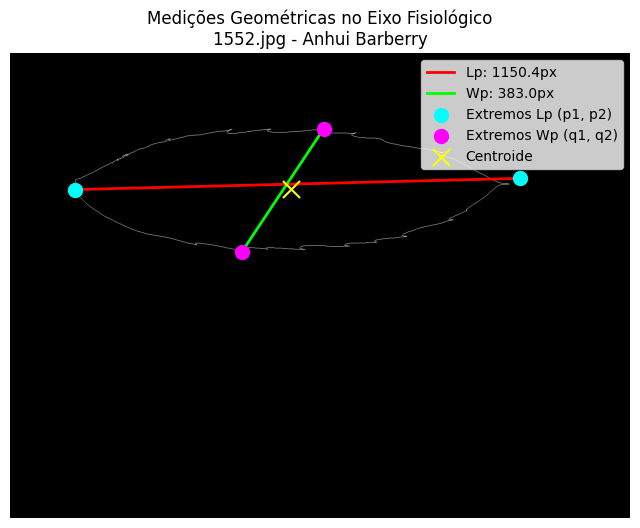

In [61]:
def obter_pontos_extremos_e_geometria(pontos_borda, binaria):
    centroide, X_centralizado, u1, u2 = calcular_pca_borda(pontos_borda)

    R = np.vstack((u1, u2))
    pontos_rotacionados = np.dot(X_centralizado, R.T)

    idx_p1 = np.argmin(pontos_rotacionados[:, 0])
    idx_p2 = np.argmax(pontos_rotacionados[:, 0])

    idx_q1 = np.argmin(pontos_rotacionados[:, 1])
    idx_q2 = np.argmax(pontos_rotacionados[:, 1])

    p1 = pontos_borda[idx_p1].astype(float)
    p2 = pontos_borda[idx_p2].astype(float)
    q1 = pontos_borda[idx_q1].astype(float)
    q2 = pontos_borda[idx_q2].astype(float)

    vetor_comprimento = p2 - p1
    direcao_Lp = vetor_comprimento / np.linalg.norm(vetor_comprimento)
    direcao_Wp = np.array([-direcao_Lp[1], direcao_Lp[0]])

    coords = pontos_borda.astype(float)
    if len(coords) > 2000:
        passos = len(coords) // 1000
        coords_sampled = coords[::passos]
    else:
        coords_sampled = coords

    diff = coords_sampled[:, None, :] - coords_sampled[None, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

    D = np.max(dist_matrix)
    A = float(np.sum(binaria))
    P = float(pontos_borda.shape[0])

    Lp = float(np.linalg.norm(p2 - p1))
    Wp = float(np.linalg.norm(q2 - q1))

    caracteristicas_geometricas = {
        'D': D, 'A': A, 'P': P, 'Lp': Lp, 'Wp': Wp,
        'p1': p1, 'p2': p2, 'q1': q1, 'q2': q2, 'centroide': centroide
    }
    return caracteristicas_geometricas


###### Visualizacao ########

ID_TESTE = 1552

if 'folhas_dados_direto' in globals() and ID_TESTE in folhas_dados_direto:
    img_original = folhas_dados_direto[ID_TESTE]

    nome_especie = obter_nome_especie_por_id_arquivo(ID_TESTE)

    img_cinza = converter_para_cinza(img_original)
    img_binaria = binarizar_imagem(img_cinza)
    pontos_borda = obter_pixels_borda(img_binaria)

    geom = obter_pontos_extremos_e_geometria(pontos_borda, img_binaria)

    D, A, P, Lp, Wp = geom['D'], geom['A'], geom['P'], geom['Lp'], geom['Wp']
    p1, p2, q1, q2 = geom['p1'], geom['p2'], geom['q1'], geom['q2']
    centroide = geom['centroide']

    matriz_borda_visual = np.zeros_like(img_binaria)
    if len(pontos_borda) > 0:
        matriz_borda_visual[pontos_borda[:, 1], pontos_borda[:, 0]] = 1

    print("="*65)
    print(f"CARACTERÍSTICAS GEOMÉTRICAS E EXTREMOS - ID: {ID_TESTE}")
    print(f"ESPÉCIE: {nome_especie.upper()}")
    print("="*65)
    print(f"1. Diâmetro (D):                    {D:.2f} pixels")
    print(f"2. Área (A):                        {A:.1f} pixels")
    print(f"3. Perímetro (P):                   {P:.1f} pixels")
    print(f"4. Comprimento Fisiológico (Lp):    {Lp:.2f} pixels")
    print(f"5. Largura Fisiológica (Wp):        {Wp:.2f} pixels")
    print("-"*65)
    print(f"Extremo p1 (comprimento):           ({p1[0]:.2f}, {p1[1]:.2f})")
    print(f"Extremo p2 (comprimento):           ({p2[0]:.2f}, {p2[1]:.2f})")
    print(f"Extremo q1 (largura):               ({q1[0]:.2f}, {q1[1]:.2f})")
    print(f"Extremo q2 (largura):               ({q2[0]:.2f}, {q2[1]:.2f})")
    print(f"Centroide da Folha:                 ({centroide[0]:.2f}, {centroide[1]:.2f})")
    print("="*65)

    plt.figure(figsize=(8, 8))

    plt.imshow(matriz_borda_visual, cmap='gray')

    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', linestyle='-', linewidth=2, label=f'Lp: {Lp:.1f}px')

    plt.plot([q1[0], q2[0]], [q1[1], q2[1]], color='lime', linestyle='-', linewidth=2, label=f'Wp: {Wp:.1f}px')

    plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], color='cyan', marker='o', s=100, zorder=5, label='Extremos Lp (p1, p2)')
    plt.scatter([q1[0], q2[0]], [q1[1], q2[1]], color='magenta', marker='o', s=100, zorder=5, label='Extremos Wp (q1, q2)')

    plt.scatter(centroide[0], centroide[1], color='yellow', marker='x', s=150, zorder=6, label='Centroide')

    plt.title(f"Medições Geométricas no Eixo Fisiológico\n{ID_TESTE}.jpg - {nome_especie}")
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()
else:
    print(f"Erro: O ID {ID_TESTE} não foi encontrado dentro do dicionário 'folhas_dados_direto'.")

5 - Operações Morfológicas de Erosão para Fator de Suavização

Para a primeira característica morfológica (o Fator de Suavização $S$), é aplicado uma erosão morfológica na imagem binária da folha utilizando elementos estruturantes de formato quadrado de $5 \times 5$ e $3 \times 3$, calculando a razão entre as áreas resultantes:  

$$S = \frac{\text{Área}(\text{Erosão}_{5\times5})}{\text{Área}(\text{Erosão}_{3\times3})}$$

PROCESSAMENTO MORFOLÓGICO - ID DO DATASET: 1552
NOME DA ESPÉCIE: ANHUI BARBERRY
1. Área após Erosão 3x3:            244533.0 pixels
2. Área após Erosão 5x5:            241574.0 pixels
3. Fator de Suavização (S):         0.987899


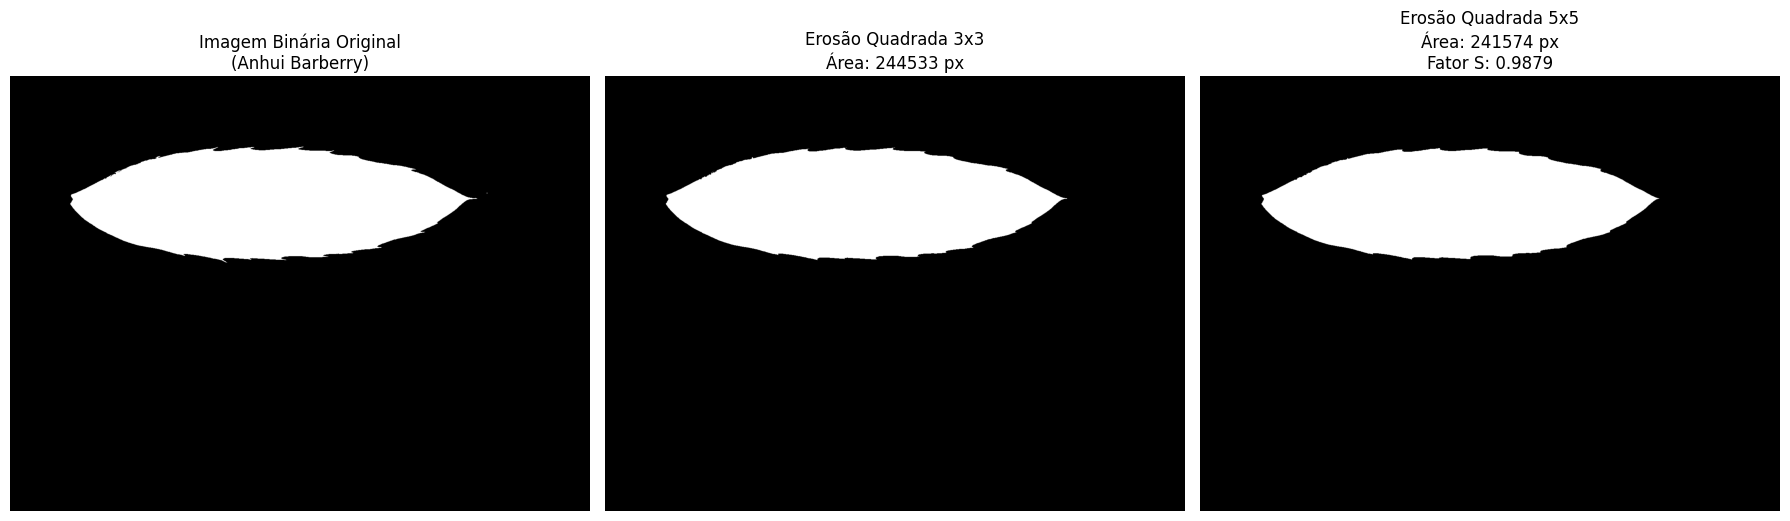

In [63]:
def erosao_manual(binaria, tamanho_kernel):
    H, W = binaria.shape
    borda_pad = tamanho_kernel // 2
    img_erodida = np.zeros_like(binaria)

    for y in range(borda_pad, H - borda_pad):
        for x in range(borda_pad, W - borda_pad):
            sub_matriz = binaria[y - borda_pad : y + borda_pad + 1, x - borda_pad : x + borda_pad + 1]
            if np.all(sub_matriz == 1):
                img_erodida[y, x] = 1

    return img_erodida

def calcular_fator_suavizacao(binaria):
    erodida_3 = erosao_manual(binaria, 3)
    erodida_5 = erosao_manual(binaria, 5)

    area_3 = float(np.sum(erodida_3))
    area_5 = float(np.sum(erodida_5))

    if area_3 == 0:
        return 0.0
    return area_5 / area_3


###### Visualizacao ########

ID_TESTE = 1552

if 'folhas_dados_direto' in globals() and ID_TESTE in folhas_dados_direto:
    img_original = folhas_dados_direto[ID_TESTE]

    nome_especie = obter_nome_especie_por_id_arquivo(ID_TESTE)

    img_cinza = converter_para_cinza(img_original)
    img_binaria = binarizar_imagem(img_cinza)

    erodida_3 = erosao_manual(img_binaria, 3)
    erodida_5 = erosao_manual(img_binaria, 5)

    area_3 = float(np.sum(erodida_3))
    area_5 = float(np.sum(erodida_5))
    fator_s = calcular_fator_suavizacao(img_binaria)

    print("="*65)
    print(f"PROCESSAMENTO MORFOLÓGICO - ID DO DATASET: {ID_TESTE}")
    print(f"NOME DA ESPÉCIE: {nome_especie.upper()}")
    print("="*65)
    print(f"1. Área após Erosão 3x3:            {area_3:.1f} pixels")
    print(f"2. Área após Erosão 5x5:            {area_5:.1f} pixels")
    print(f"3. Fator de Suavização (S):         {fator_s:.6f}")
    print("="*65)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_binaria, cmap='gray')
    axes[0].set_title(f"Imagem Binária Original\n({nome_especie})")
    axes[0].axis('off')

    axes[1].imshow(erodida_3, cmap='gray')
    axes[1].set_title(f"Erosão Quadrada 3x3\nÁrea: {area_3:.0f} px")
    axes[1].axis('off')

    axes[2].imshow(erodida_5, cmap='gray')
    axes[2].set_title(f"Erosão Quadrada 5x5\nÁrea: {area_5:.0f} px\nFator S: {fator_s:.4f}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Erro: O ID {ID_TESTE} não foi encontrado dentro do dicionário 'folhas_dados_direto'.")

6 - Características Morfológicas Digitais da Folha

Foram combinados as métricas geométricas e a suavização para derivar as primeiras características morfológicas digitais:  

1- Fator de Suavização ($S$)   

2- Proporção de Aspecto: $\frac{L_p}{W_p}$   

3- Fator de Forma: $\frac{4\pi A}{P^2}$   

4- Retangularidade: $\frac{L_p \cdot W_p}{A}$   

5- Fator de Estreitamento: $\frac{D}{L_p}$   

6- Razão Perímetro-Diâmetro: $\frac{P}{D}$   

7- Razão Perímetro-Medidas-Fisiológicas: $\frac{P}{L_p + W_p}$   

CARACTERÍSTICAS MORFOLÓGICAS DIGITAIS - ID: 1552
ESPÉCIE: ANHUI BARBERRY
1. Fator de Suavização (S):                    0.987899
2. Proporção de Aspecto (Lp / Wp):             3.003402
3. Fator de Forma (4*pi*A / P^2):              0.457541
4. Retangularidade (Lp * Wp / A):              1.777831
5. Fator de Estreitamento (D / Lp):            0.999109
6. Razão Perímetro-Diâmetro (P / D):           2.269996
7. Razão Perímetro-Medidas (P / (Lp+Wp)):      1.701463


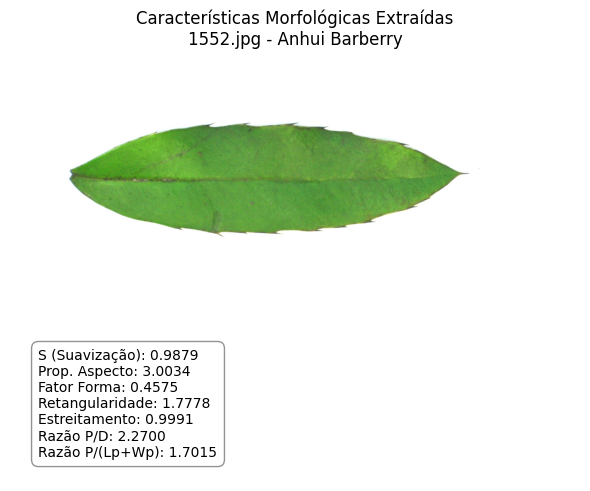

In [64]:
def extrair_caracteristicas_morfologicas(img_original):
    img_gray = converter_para_cinza(img_original)
    binaria = binarizar_imagem(img_gray)
    pontos_borda = obter_pixels_borda(binaria)

    geom = obter_pontos_extremos_e_geometria(pontos_borda, binaria)

    D, A, P, Lp, Wp = geom['D'], geom['A'], geom['P'], geom['Lp'], geom['Wp']

    S = calcular_fator_suavizacao(binaria)
    proporcao_aspecto = Lp / Wp
    fator_forma = (4 * np.pi * A) / (P ** 2)
    retangularidade = (Lp * Wp) / A
    fator_estreitamento = D / Lp
    razao_p_d = P / D
    razao_p_lp_wp = P / (Lp + Wp)

    vetor_caracteristicas = np.array([
        S, proporcao_aspecto, fator_forma, retangularidade,
        fator_estreitamento, razao_p_d, razao_p_lp_wp
    ])

    return vetor_caracteristicas, geom


###### Visualizacao ########

ID_TESTE = 1552

if 'folhas_dados_direto' in globals() and ID_TESTE in folhas_dados_direto:
    img_original = folhas_dados_direto[ID_TESTE]

    nome_especie = obter_nome_especie_por_id_arquivo(ID_TESTE)

    vetor_caracteristicas, geom = extrair_caracteristicas_morfologicas(img_original)

    S = vetor_caracteristicas[0]
    proporcao_aspecto = vetor_caracteristicas[1]
    fator_forma = vetor_caracteristicas[2]
    retangularidade = vetor_caracteristicas[3]
    fator_estreitamento = vetor_caracteristicas[4]
    razao_p_d = vetor_caracteristicas[5]
    razao_p_lp_wp = vetor_caracteristicas[6]

    print("="*65)
    print(f"CARACTERÍSTICAS MORFOLÓGICAS DIGITAIS - ID: {ID_TESTE}")
    print(f"ESPÉCIE: {nome_especie.upper()}")
    print("="*65)
    print(f"1. Fator de Suavização (S):                    {S:.6f}")
    print(f"2. Proporção de Aspecto (Lp / Wp):             {proporcao_aspecto:.6f}")
    print(f"3. Fator de Forma (4*pi*A / P^2):              {fator_forma:.6f}")
    print(f"4. Retangularidade (Lp * Wp / A):              {retangularidade:.6f}")
    print(f"5. Fator de Estreitamento (D / Lp):            {fator_estreitamento:.6f}")
    print(f"6. Razão Perímetro-Diâmetro (P / D):           {razao_p_d:.6f}")
    print(f"7. Razão Perímetro-Medidas (P / (Lp+Wp)):      {razao_p_lp_wp:.6f}")
    print("="*65)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    plt.title(f"Características Morfológicas Extraídas\n{ID_TESTE}.jpg - {nome_especie}")

    texto_morfologia = (
        f"S (Suavização): {S:.4f}\n"
        f"Prop. Aspecto: {proporcao_aspecto:.4f}\n"
        f"Fator Forma: {fator_forma:.4f}\n"
        f"Retangularidade: {retangularidade:.4f}\n"
        f"Estreitamento: {fator_estreitamento:.4f}\n"
        f"Razão P/D: {razao_p_d:.4f}\n"
        f"Razão P/(Lp+Wp): {razao_p_lp_wp:.4f}"
    )

    plt.gca().text(0.05, 0.05, texto_morfologia, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='bottom',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'))

    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"Erro: O ID {ID_TESTE} não foi encontrado dentro do dicionário 'folhas_dados_direto'.")

7 - Visualização e Validação do Alinhamento PCA

Foram plotados a imagem com os eixos ortogonais principais de rotação calculados automaticamente sobrepostos à borda , evidenciando que os pontos extremos $p_1, p_2$ delimitam o comprimento longitudinal e $q_1, q_2$ determinam a largura transversal máxima ortogonal da folha.

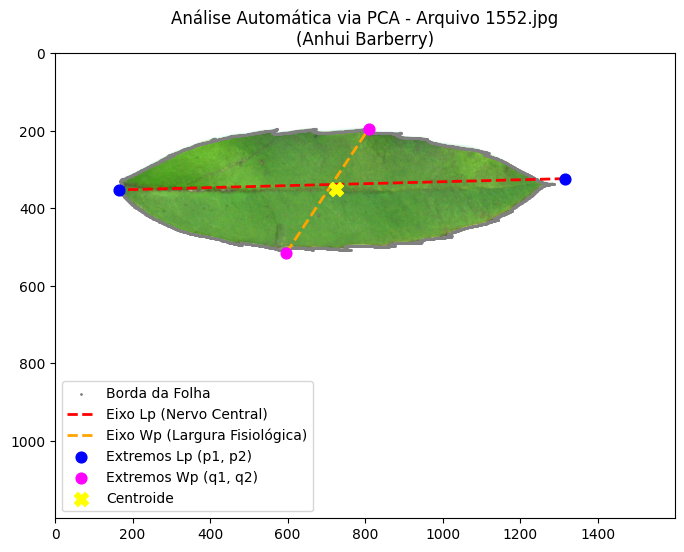

In [65]:
def plotar_analise_pca_folha(id_arquivo, dataset):
    if id_arquivo not in dataset:
        print(f"Imagem {id_arquivo} não encontrada no dataset local.")
        return

    img = dataset[id_arquivo]
    img_gray = converter_para_cinza(img)
    binaria = binarizar_imagem(img_gray)
    pontos_borda = obter_pixels_borda(binaria)

    geom = obter_pontos_extremos_e_geometria(pontos_borda, binaria)

    p1, p2 = geom['p1'], geom['p2']
    q1, q2 = geom['q1'], geom['q2']
    centroide = geom['centroide']

    nome_especie = obter_nome_especie_por_id_arquivo(id_arquivo)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    plt.scatter(pontos_borda[:, 0], pontos_borda[:, 1], c='gray', s=1, label='Borda da Folha')

    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='red', linestyle='--', linewidth=2, label='Eixo Lp (Nervo Central)')
    plt.plot([q1[0], q2[0]], [q1[1], q2[1]], color='orange', linestyle='--', linewidth=2, label='Eixo Wp (Largura Fisiológica)')

    plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], color='blue', s=60, zorder=5, label='Extremos Lp (p1, p2)')
    plt.scatter([q1[0], q2[0]], [q1[1], q2[1]], color='magenta', s=60, zorder=5, label='Extremos Wp (q1, q2)')
    plt.scatter(centroide[0], centroide[1], color='yellow', marker='X', s=100, zorder=6, label='Centroide')

    plt.title(f"Análise Automática via PCA - Arquivo {id_arquivo}.jpg\n({nome_especie})")
    plt.legend()
    plt.axis('on')
    plt.show()

ID_TESTE = 1552

plotar_analise_pca_folha(ID_TESTE, folhas_dados_direto)